Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Previewing the data

In [ ]:
# loading the dataset into the notebook
df = pd.read_csv('f1_race_driver_rows.csv')

# previewing the df
df.tail()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner
3619,2026,3,Japanese Grand Prix,PIA,McLaren,3,3.0,2,Finished,18.0,0
3620,2026,3,Japanese Grand Prix,RUS,Mercedes,2,2.0,4,Finished,12.0,0
3621,2026,3,Japanese Grand Prix,SAI,Williams,16,16.0,15,Finished,0.0,0
3622,2026,3,Japanese Grand Prix,STR,Aston Martin,22,22.0,21,DNF,0.0,0
3623,2026,3,Japanese Grand Prix,VER,Red Bull,11,11.0,8,Finished,4.0,0


In [ ]:
# getting the number of rows and columns in the df
df.shape

(3624, 11)

# Cleaning the data

In [ ]:
# looking at how many null values are in each column
df.isnull().sum()

,0
season,0
round,0
race_name,0
driver,0
team,0
grid_position,0
quali_position,4
finish_position,0
status,0
points,0


In [ ]:
# here we are selecting all of the records with a null value in the 'quali_position' column
df[df['quali_position'].isnull()][

    # below is a list of all the columns we want to view from the null records
    ['season','race_name','driver','grid_position','status', 'quali_position']
]

,season,race_name,driver,grid_position,status,quali_position
460,2019,Chinese Grand Prix,ALB,0,+1 Lap,NaN
463,2019,Chinese Grand Prix,GIO,19,+1 Lap,NaN
1308,2021,Monaco Grand Prix,MSC,20,+3 Laps,NaN
3482,2025,São Paulo Grand Prix,BOR,18,Retired,NaN


In [ ]:
# here we are filling the null values in the 'quali_position' column with the values in the 'grid_position' column
df['quali_position'] = df['quali_position'].fillna(df['grid_position'])

In [ ]:
# here we are using the same code as before to check that there are no more null values in the records
df[df['quali_position'].isnull()][
    ['race_name', 'quali_position'] # using less columns for simplicity
]

,race_name,quali_position


In [ ]:
df.isnull().sum() # just another sanity check

,0
season,0
round,0
race_name,0
driver,0
team,0
grid_position,0
quali_position,0
finish_position,0
status,0
points,0


Further checks:

there is a problem with the data in the 'grid_position' column. some records record a drivers starting positon on the grid as being 0. drivers can only start on positions 1-20. with the grid position being 0, this could mean that a driver started in the pit lane or something else

In [ ]:
# here we are returning all of the records where the driver is said to have started at position 0
df[df['grid_position'] == 0]

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner
186,2018,10,British Grand Prix,HAR,Toro Rosso,0,20.0,20,Power Unit,0.0,0
460,2019,3,Chinese Grand Prix,ALB,Toro Rosso,0,0.0,10,+1 Lap,1.0,0
482,2019,4,Azerbaijan Grand Prix,GAS,Red Bull Racing,0,20.0,17,Transmission,0.0,0
487,2019,4,Azerbaijan Grand Prix,KUB,Williams,0,18.0,16,+2 Laps,0.0,0
493,2019,4,Azerbaijan Grand Prix,RAI,Alfa Romeo Racing,0,19.0,10,+1 Lap,1.0,0
506,2019,5,Spanish Grand Prix,HUL,Renault,0,16.0,13,Finished,0.0,0
550,2019,7,Canadian Grand Prix,MAG,Haas F1 Team,0,10.0,17,+2 Laps,0.0,0
595,2019,9,Austrian Grand Prix,RUS,Williams,0,19.0,18,+2 Laps,0.0,0
667,2019,13,Belgian Grand Prix,KUB,Williams,0,20.0,17,+1 Lap,0.0,0
693,2019,14,Italian Grand Prix,RAI,Alfa Romeo Racing,0,10.0,15,+1 Lap,0.0,0


In [ ]:
# here we are getting a preview of some of the records to see if there is a patern as to why they are starting on pos 0
df[df['grid_position'] == 0][
    ['season','race_name','driver','quali_position','finish_position','status']
].head(20)

,season,race_name,driver,quali_position,finish_position,status
186,2018,British Grand Prix,HAR,20.0,20,Power Unit
460,2019,Chinese Grand Prix,ALB,0.0,10,+1 Lap
482,2019,Azerbaijan Grand Prix,GAS,20.0,17,Transmission
487,2019,Azerbaijan Grand Prix,KUB,18.0,16,+2 Laps
493,2019,Azerbaijan Grand Prix,RAI,19.0,10,+1 Lap
506,2019,Spanish Grand Prix,HUL,16.0,13,Finished
550,2019,Canadian Grand Prix,MAG,10.0,17,+2 Laps
595,2019,Austrian Grand Prix,RUS,19.0,18,+2 Laps
667,2019,Belgian Grand Prix,KUB,20.0,17,+1 Lap
693,2019,Italian Grand Prix,RAI,10.0,15,+1 Lap


In [ ]:
# checking the actual number of records where the driver started in position 0
(df['grid_position'] == 0).sum()

np.int64(44)

as of right now we are going to assume that in this dataset whenever a driver is said to be starting at position 0 then that means they started from the pit lane. we are going to change these values to 20 to indicate that they started at the very back of the pack

In [ ]:
# setting all drivers who started in the pit lane to the back of the grid
df.loc[df['grid_position'] == 0, 'grid_position'] = 20

# checking to make sure that it worked
(df['grid_position'] == 0).sum()

np.int64(0)

Checking for class imbalance:



In [ ]:
df['is_winner'].value_counts()
df['is_winner'].value_counts(normalize=True)

,proportion
is_winner,
0,0.950055
1,0.049945


In [ ]:
# this is to show how many winners there are from each starting position on the grid
pd.crosstab(df['is_winner'], df['grid_position'])

grid_position,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
is_winner,,,,,,,,,,,,,,,,,,,,,,
0,83,140,161,175,179,176,179,179,180,177,180,181,179,178,180,179,181,178,179,193,3,3
1,98,41,20,6,2,5,1,1,1,3,0,0,0,2,0,0,1,0,0,0,0,0


Removing feature leakage:

because we are making a prediction before the race, we cant have any data in our data set that cant be known at the start of the race. the following columns will need to be removed as they fit this criteria.

1) Finish Position
2) points
3) Status
4) is_winner

as stated before, the data in these columns can only be known at the end of the race

In [ ]:
# these are the columns we are dropping as this is information we would only know after the race has ended
X = df.drop(columns = ['finish_position', 'points', 'status', 'is_winner'])
y = df['is_winner'] # we want to keep this as this is our target variable

X.head() # checking that the correct columns were dropped

,season,round,race_name,driver,team,grid_position,quali_position
0,2018,1,Australian Grand Prix,ALO,McLaren,10,11.0
1,2018,1,Australian Grand Prix,BOT,Mercedes,15,10.0
2,2018,1,Australian Grand Prix,ERI,Sauber,17,17.0
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,20,20.0
4,2018,1,Australian Grand Prix,GRO,Haas F1 Team,6,7.0


Removing all the duplicate data

In [ ]:
# here we have code to delete all duplicated records from the df
df = df.drop_duplicates()

# checking the duplicates are gone
df.duplicated().sum()

np.int64(0)

Fixing grid position error

In [ ]:
# changing the grid position of drivers who started in the pit lane from 0 to 20
# this is because the model may assume that drivers who start in the pit lane have a greater chance of winner
df.loc[df['grid_position'] == 0, 'grid_position'] = 20

In [ ]:
# grouping the season and round columns and then showing the number of records with more than or less than one winner
winner_counts = df.groupby(['season','round'])['is_winner'].sum()

print("Races with 0 winners:", (winner_counts == 0).sum())
print("Races with >1 winner:", (winner_counts > 1).sum())

Races with 0 winners: 0
Races with >1 winner: 0


# Engineering rolling features

adding features to show a drivers rolling performance over the last couple of races

In [ ]:
# Sort chronologically
df = df.sort_values(['season', 'round'])

# ---- DRIVER ROLLING FEATURES ---- #

# Rolling average finish (last 3 races)
df['driver_avg_finish_3'] = ( # creating a new column in the df
    df.groupby('driver')['finish_position'] # grouping the driver and finish position column together to calc average wins
      .shift(1) # using this line to only use data from the previous races for each record
      .rolling(3, min_periods=1) # using the rolling function to use the last 3 races
      .mean() # calculating the average wins over the last races
)

# Rolling win rate (last 5 races)
df['driver_win_rate_5'] = (
    df.groupby('driver')['finish_position']
      .shift(1)
      .rolling(5, min_periods=1) # using the rolling function to use the last 5 races
      .apply(lambda x: (x == 1).mean()) # code to calculate a proportion or the rate within a given window
)

# ---- TEAM ROLLING FEATURES ---- #

df['team_win_rate_5'] = ( # creating a new column in the df
    df.groupby('team')['finish_position'] # grouping the team and finish position columns
      .shift(1) # only use the data from the previous records for each record
      .rolling(5, min_periods=1) # rolling function to use the last 5 races
      .apply(lambda x: (x == 1).mean())
)

In [ ]:
# code below is used to fill in any null values with the medium
df[['driver_avg_finish_3',
    'driver_win_rate_5',
    'team_win_rate_5']] = df[[
    'driver_avg_finish_3',
    'driver_win_rate_5',
    'team_win_rate_5'
]].fillna(df[['driver_avg_finish_3',
              'driver_win_rate_5',
              'team_win_rate_5']].median())

In [ ]:
df.tail()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner,driver_avg_finish_3,driver_win_rate_5,team_win_rate_5
3619,2026,3,Japanese Grand Prix,PIA,McLaren,3,3.0,2,Finished,18.0,0,16.000000,0.0,0.0
3620,2026,3,Japanese Grand Prix,RUS,Mercedes,2,2.0,4,Finished,12.0,0,12.000000,0.0,0.2
3621,2026,3,Japanese Grand Prix,SAI,Williams,16,16.0,15,Finished,0.0,0,10.000000,0.0,0.2
3622,2026,3,Japanese Grand Prix,STR,Aston Martin,22,22.0,21,DNF,0.0,0,9.666667,0.0,0.2
3623,2026,3,Japanese Grand Prix,VER,Red Bull,11,11.0,8,Finished,4.0,0,14.333333,0.0,0.2


Adding feature to show champion ranking

In [ ]:
# Sort first (critical)
# we sort first so that we know we are using previously gained points for each record
df = df.sort_values(['season', 'round'])

df['cumulative_points'] = ( # creating a new column to store points accumulated from previous races
    df.groupby(['season', 'driver'])['points']
      .apply(lambda x: x.shift(1).cumsum())
      .reset_index(level=[0,1], drop=True)
)

In [ ]:
df.tail()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner,driver_avg_finish_3,driver_win_rate_5,team_win_rate_5,cumulative_points
3619,2026,3,Japanese Grand Prix,PIA,McLaren,3,3.0,2,Finished,18.0,0,16.000000,0.0,0.0,0.0
3620,2026,3,Japanese Grand Prix,RUS,Mercedes,2,2.0,4,Finished,12.0,0,12.000000,0.0,0.2,43.0
3621,2026,3,Japanese Grand Prix,SAI,Williams,16,16.0,15,Finished,0.0,0,10.000000,0.0,0.2,2.0
3622,2026,3,Japanese Grand Prix,STR,Aston Martin,22,22.0,21,DNF,0.0,0,9.666667,0.0,0.2,0.0
3623,2026,3,Japanese Grand Prix,VER,Red Bull,11,11.0,8,Finished,4.0,0,14.333333,0.0,0.2,8.0


In [ ]:
# keep this!!!!!!!!!!!!!!!!!!!!
df['champ_rank'] = (
    df.groupby(['season','round'])['cumulative_points']
      .rank(ascending=False, method='first')
)

In [ ]:
# filling in null values with the maximum value
df['champ_rank'] = df['champ_rank'].fillna(df['champ_rank'].max())

In [ ]:
# fill missing values with 0 in the cumulative points column
# if a null value comes up that just means that no points have been earned yet
df['cumulative_points'] = df['cumulative_points'].fillna(0) # keep this!!!!!!!!!!!!!!!!!

#
df['champ_rank'] = df.groupby('season')['champ_rank'] \
                      .transform(lambda x: x.fillna(x.max()))

In [ ]:
df.tail()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner,driver_avg_finish_3,driver_win_rate_5,team_win_rate_5,cumulative_points,champ_rank
3619,2026,3,Japanese Grand Prix,PIA,McLaren,3,3.0,2,Finished,18.0,0,16.000000,0.0,0.0,0.0,21.0
3620,2026,3,Japanese Grand Prix,RUS,Mercedes,2,2.0,4,Finished,12.0,0,12.000000,0.0,0.2,43.0,2.0
3621,2026,3,Japanese Grand Prix,SAI,Williams,16,16.0,15,Finished,0.0,0,10.000000,0.0,0.2,2.0,13.0
3622,2026,3,Japanese Grand Prix,STR,Aston Martin,22,22.0,21,DNF,0.0,0,9.666667,0.0,0.2,0.0,22.0
3623,2026,3,Japanese Grand Prix,VER,Red Bull,11,11.0,8,Finished,4.0,0,14.333333,0.0,0.2,8.0,8.0


Adding interactive features

In [ ]:
# this feature aims to capture the interaction between the position a driver starts a race and their recent form
df['grid_x_form'] = df['grid_position'] * df['driver_avg_finish_3']
df['champ_x_grid'] = df['champ_rank'] * df['grid_position']
df['team_form_x_grid'] = df['team_win_rate_5'] * df['grid_position']

In [ ]:
race_key = df[['season', 'round', 'race_name', 'driver']].copy()

In [ ]:
# code to show all the columns in the df after engineering new features
pd.set_option('display.max_columns', None)
df.head()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner,driver_avg_finish_3,driver_win_rate_5,team_win_rate_5,cumulative_points,champ_rank,grid_x_form,champ_x_grid,team_form_x_grid
0,2018,1,Australian Grand Prix,ALO,McLaren,10,11.0,5,Finished,10.0,0,10.333333,0.0,0.0,0.0,22.0,103.333333,220.0,0.0
1,2018,1,Australian Grand Prix,BOT,Mercedes,15,10.0,8,Finished,4.0,0,10.333333,0.0,0.0,0.0,22.0,155.000000,330.0,0.0
2,2018,1,Australian Grand Prix,ERI,Sauber,17,17.0,19,Steering,0.0,0,10.333333,0.0,0.0,0.0,22.0,175.666667,374.0,0.0
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,20,20.0,18,Engine,0.0,0,10.333333,0.0,0.0,0.0,22.0,206.666667,440.0,0.0
4,2018,1,Australian Grand Prix,GRO,Haas F1 Team,6,7.0,16,Wheel,0.0,0,10.333333,0.0,0.0,0.0,22.0,62.000000,132.0,0.0


In [ ]:
# write me code to output all of the names of the columns in the df
print(df.columns)

Index(['season', 'round', 'race_name', 'driver', 'team', 'grid_position',
       'quali_position', 'finish_position', 'status', 'points', 'is_winner',
       'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5',
       'cumulative_points', 'champ_rank', 'grid_x_form', 'champ_x_grid',
       'team_form_x_grid'],
      dtype='object')


# Creating a baseline logistical regression model

using one-hot encode

we need to use one-hot encode to change our categorical data, such as 'driver' into numerical data so that our model will be able to understand the data easier.

if we were to give each driver a numer for example, the model may think there is some sort of heirarchy between the drivers. instead we will give each driver a sort of code which isnt ordinal

In [ ]:
# Example target: driver won race if they finished P1
y = (df['finish_position'] == 1).astype(int)

# the features the model will be trained on
X = df[['season',
        'round',
        'grid_position',
        'quali_position',
        'driver',
        'team',
        'race_name',
        'driver_avg_finish_3',
        'driver_win_rate_5',
        'team_win_rate_5',
        'cumulative_points',
        'champ_rank',
        'grid_x_form',
        'champ_x_grid',
        'team_form_x_grid']].copy()

In [ ]:
# pd.get_dummies allows us to one-hot encode categorical values into numerical data

# we use the drop_first = True code to prevent "multicollinearity" which
# basically means its removing redundant columns created by one-hot encoding
# for any new categorical data we include in the main df we will need to add the column here
X = pd.get_dummies(X, columns=['driver', 'team', 'race_name'], drop_first=True)

# Training Logistical Regression baseline

In [ ]:
train_mask = df['season'] < 2025 # we are training the model on races from seasons 2018 - 2024
test_mask = df['season'] == 2025 # we will test on season 2025

X_train = X.loc[train_mask] # we apply the filter onto our X_train data set
X_test = X.loc[test_mask] # and we do the same for the X_test data set

y_train = y.loc[train_mask] # the data from the 2025 season will be here
y_test = y.loc[test_mask]

In [ ]:
# importing the Logistical regression model from the library
from sklearn.linear_model import LogisticRegression

# creating an instance of the logistal regression model
# we give it 1000 training itterations to work with
# and we set the class weights to balanced
model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')

# here we fit the model onto the training data
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_probs)
print("ROC AUC:", roc_auc)

# result closer to 1.0 is really good!!!!!
# result closer to 0.0 is really bad!!!!!

ROC AUC: 0.9687728937728938


In [ ]:
X_test_eval = X_test.copy()
X_test_eval['prob'] = y_probs
X_test_eval['race_name'] = df.loc[test_mask, 'race_name'].values
X_test_eval['actual'] = y_test.values

correct = 0
total_races = X_test_eval['race_name'].nunique()

for race in X_test_eval['race_name'].unique():
    race_data = X_test_eval[X_test_eval['race_name'] == race]
    predicted = race_data.loc[race_data['prob'].idxmax()]

    if predicted['actual'] == 1:
        correct += 1

print("Race-level accuracy:", correct / total_races)

# a result closer to 1.0 is really good!!!
# a result closer to 0.0 is really bad!!!

Race-level accuracy: 0.625


In [ ]:
race = "Australian Grand Prix"

race_data = X_test_eval[X_test_eval['race_name'] == race]
race_data = race_data.sort_values('prob', ascending=False)

race_data[['prob','actual']].head(5)

,prob,actual
3071,0.948634,1
3078,0.941771,0
3073,0.889948,0
3074,0.432784,0
3077,0.346423,0


In [ ]:
ranks = []

for race in X_test_eval['race_name'].unique():
    race_data = X_test_eval[X_test_eval['race_name'] == race]
    race_data = race_data.sort_values('prob', ascending=False).reset_index()

    winner_rank = race_data[race_data['actual'] == 1].index[0] + 1
    ranks.append(winner_rank)

print("Average winner rank:", np.mean(ranks))

# a result closer to 1.0 is really good!!!
# a result closer to 0.0 is really bad!!!

# a result of 1.5 means that the true winner is predicted to be either 1st or 2nd

Average winner rank: 1.5833333333333333


# Trying Random Forest algorithm

In [ ]:
# Example target: driver won race if they finished P1
y = (df['finish_position'] == 1).astype(int)   # <-- change column name if yours differs

# the features the model will be trained on
X = df[['season',
        'round',
        'grid_position',
        'quali_position',
        'driver',
        'team',
        'race_name',
        'driver_avg_finish_3',
        'driver_win_rate_5',
        'team_win_rate_5',
        'cumulative_points',
        'champ_rank']].copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=12,          # restrict depth
    min_samples_split=10,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_probs_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

print("ROC AUC:", roc_auc_score(y_test, y_probs_rf))

# ROC AUC stands for Receiver Operating Characteristics - Area Under the Curve

# this metric is telling us how good the model is at ranking winners above losers
# with the metric being soo close to 1 means that my model is very good at this!!!

ROC AUC: 0.9757326007326007


In [ ]:
eval_df = race_key.loc[X_test.index].copy()
eval_df['y_true'] = y_test.values
eval_df['p_win'] = y_probs_rf

picked = eval_df.loc[
    eval_df.groupby(['season','round'])['p_win'].idxmax()
]

race_acc = (picked['y_true'] == 1).mean()
print("Race-level accuracy:", race_acc)

# a result of 0.708 means that the model can predict the winner 70.8% of the time

Race-level accuracy: 0.7083333333333334


In [ ]:
eval_df['rank'] = eval_df.groupby(['season','round'])['p_win'] \
                          .rank(ascending=False)

winner_ranks = eval_df[eval_df['y_true'] == 1]['rank']
print("Average winner rank:", winner_ranks.mean())

# a result of 1.458 means that the true winner is predicted to be either 1st or 2nd

Average winner rank: 1.5


### Feature Importance

This chart visualizes the importance of each feature in the Random Forest model's predictions. A higher score indicates that the feature had a greater impact on the model's decisions.

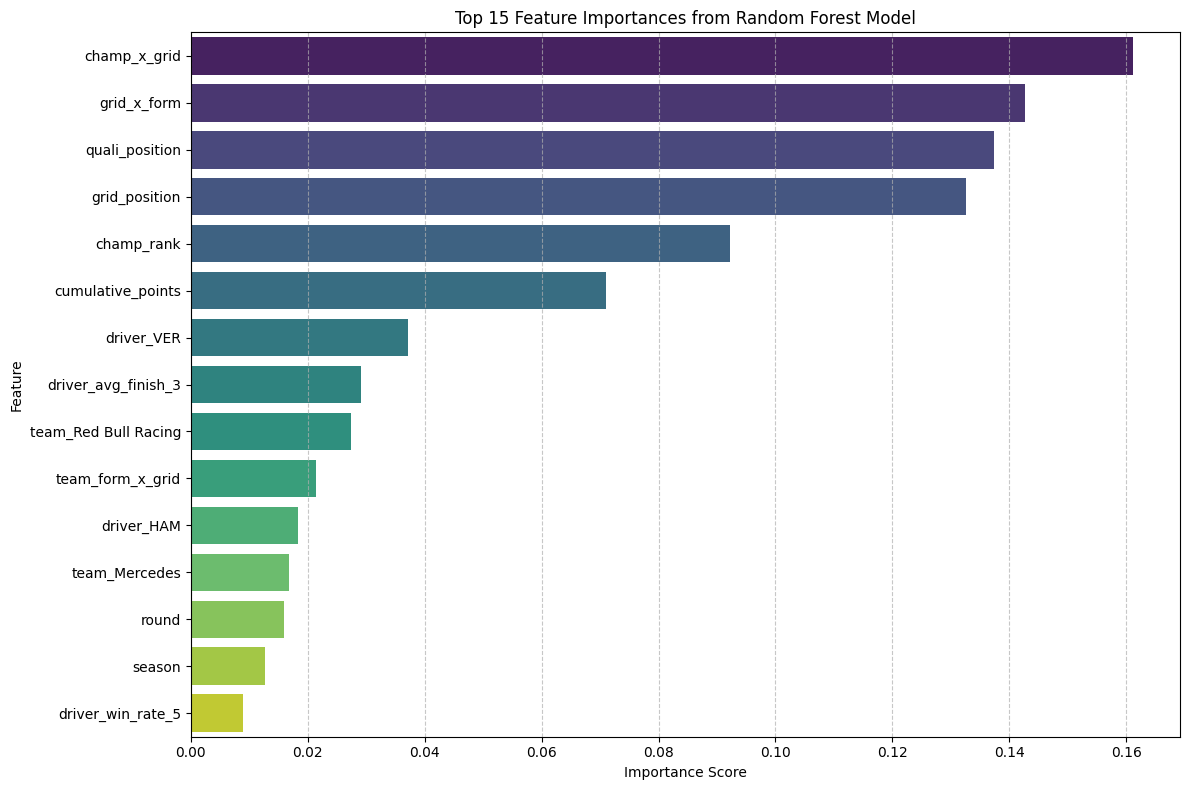

In [ ]:
# for this chunck of code we are looking at how the model prioritieses each feature in the dataset
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Get the top 15 most important features for better readability
top_15_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_features.values, y=top_15_features.index, hue=top_15_features.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  rf.predict_proba(X_test)[:, 1])

print("Train AUC:", train_auc)
print("Test  AUC:", test_auc)

Train AUC: 0.9880526011589248
Test  AUC: 0.9757326007326007


In [ ]:
print(X.dtypes.head(20))
print("Any object columns left?", (X.dtypes == 'object').any())

season                   int64
round                    int64
grid_position            int64
quali_position         float64
driver                  object
team                    object
race_name               object
driver_avg_finish_3    float64
driver_win_rate_5      float64
team_win_rate_5        float64
cumulative_points      float64
champ_rank             float64
dtype: object
Any object columns left? True


# Testing rolling season validation

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

results = []

seasons = sorted(df['season'].unique())

# Columns that are NOT model inputs (target or post-race outcomes)
# We want season, round, driver, team, race_name as features
non_features = {
    "is_winner",           # target
    "finish_position",       # post-race outcomes
    "status",              # post-race outcomes
    "points",              # post-race outcomes
    # "race_id" is not in df, so no need to exclude
    # "position", "Driver", "Abbreviation" are not in df, so no need to exclude
}

# All columns that will be used as features before one-hot encoding
feature_cols_raw = [c for c in df.columns if c not in non_features]

# Identify categorical columns that need one-hot encoding
categorical_features = ['driver', 'team', 'race_name']

for test_season in seasons:

    if test_season <= 2021:
        continue  # need earlier data to train

    train_df = df[df['season'] < test_season]
    test_df  = df[df['season'] == test_season]

    X_train_raw = train_df[feature_cols_raw]
    y_train = train_df['is_winner']

    X_test_raw = test_df[feature_cols_raw]
    y_test = test_df['is_winner']

    # Apply one-hot encoding to categorical features for training and test sets
    X_train = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True)
    X_test = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True)

    # Align columns: Ensure X_test has the same columns as X_train, filling missing with 0
    # This is crucial if a category appears in train but not test, or vice-versa.
    missing_in_test = set(X_train.columns) - set(X_test.columns)
    for col in missing_in_test:
        X_test[col] = 0
    # Drop columns in X_test that are not in X_train (e.g., new categories in test_season)
    X_test = X_test[X_train.columns]

    rf = RandomForestClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # AUC
    test_probs = rf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, test_probs)

    # Attach probs back to the original test_df for race-level evaluation
    # This requires adding the 'prob' column to test_df which still contains 'race_name'
    test_df = test_df.copy()
    test_df['prob'] = test_probs

    race_correct = []
    winner_ranks = []

    # Correct the groupby to use 'race_name' instead of 'race_id'
    for race_name, race_data in test_df.groupby('race_name'):

        race_data = race_data.sort_values('prob', ascending=False)
        actual_winner_index = race_data[race_data['is_winner'] == 1].index[0]

        predicted_winner = race_data.iloc[0]['is_winner']
        race_correct.append(predicted_winner)

        winner_rank = list(race_data.index).index(actual_winner_index) + 1
        winner_ranks.append(winner_rank)

    race_accuracy = np.mean(race_correct)
    avg_winner_rank = np.mean(winner_ranks)

    results.append({
        'season': test_season,
        'AUC': auc,
        'race_accuracy': race_accuracy,
        'avg_winner_rank': avg_winner_rank
    })

results_df = pd.DataFrame(results)
print(results_df)

   season       AUC  race_accuracy  avg_winner_rank
0    2022  0.957274       0.476190         1.904762
1    2023  0.995226       0.904762         1.142857
2    2024  0.933974       0.375000         2.375000
3    2025  0.972802       0.666667         1.541667
4    2026  1.000000       1.000000         1.000000


# Creating prediction df for race

In [ ]:
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# CHANGE NOTHING IN THIS CELL FOR GODS SAKE
# THE ONLY THINGS TO CHANGE IN THIS CELL ARE THE ROUND NUMBER AND THE NAME OF THE RACE BEING PREDICTED
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
import pandas as pd

# this function is used to build a lightweight df of info about drivers and teams which we know before race weekend
def build_round1_skeleton_df():

    # this is a list of driver code names with a comment to show who they are driving for
    # there are 22 drivers this season so there will be 22 rows in this light df
    drivers = [
        "VER","HAD", # Redbull
        "RUS","ANT", # Mercedes
        "LEC","HAM", # Ferrari
        "NOR","PIA", # Mclaren
        "ALO","STR", # Aston Marten
        "GAS","COL", # Alpine
        "LAW","LIN", # Racing Bulls
        "ALB","SAI", # Williams
        "OCO","BEA", # Haas
        "HUL","BOR", # Audi
        "PER","BOT"  # Cadillac
    ]

    # this is a list of team names
    # we include two of each team as this list needs to match the length of the 'drivers' list
    teams = [
        "Red Bull","Red Bull", # Redbull
        "Mercedes","Mercedes", # Mercedes
        "Ferrari","Ferrari",   # Ferrari
        "McLaren","McLaren",   # McLaren
        "Aston Martin","Aston Martin", # Aston Marten
        "Alpine","Alpine", # Alpine
        "Racing Bulls","Racing Bulls", # Racing Bulls
        "Williams","Williams", # Williams
        "Haas","Haas", # Hass
        "Audi","Audi", # Audi
        "Cadillac","Cadillac" # Cadillac
    ]

    # here is where we build the dataframe with the constant info that we know pre-race/qualifiers
    df = pd.DataFrame({

        #the next 3 columns in this df will be repeated for every driver in the df
        "season": 2026, # this is to show we are predicting a 2026 race
        "round": 3, # this is to show that this is the first round in the season
        "race_name": "Japanese Grand Prix", # the race circuit for the first round
        "driver": drivers, # putting all the drivers codes in the df
        "team": teams # putting all the team names into the df with their respected drivers
    })

    return df # returning the df

# 'future_df' is how we refere to this new df and we store the output of the fucntion in this var
future_df = build_round1_skeleton_df()
future_df.head() # previewing the 'future_df'

,season,round,race_name,driver,team
0,2026,3,Japanese Grand Prix,VER,Red Bull
1,2026,3,Japanese Grand Prix,HAD,Red Bull
2,2026,3,Japanese Grand Prix,RUS,Mercedes
3,2026,3,Japanese Grand Prix,ANT,Mercedes
4,2026,3,Japanese Grand Prix,LEC,Ferrari


In [ ]:
quali_results_2026 = {
    "RUS" : 6, # george russel
    "ANT" : 2, # Kimi Antonelli
    "HAD" : 9, # Issac Hadjar
    "LEC" : 4, # Charels leclerc
    "PIA" : 3, # Oscar Piastri
    "NOR" : 1, # Lando Norris
    "HAM" : 7, # Lewis Hamilton
    "LAW" : 15, # Liam Lawson
    "LIN" : 22, # Arvid lindblad
    "BOR" : 11, # Gabriell Bortolette
    "HUL" : 12, # Niko Hulkenburgh
    "BEA" : 13, # Oliver Bearman
    "OCO" : 16, # Estaban Ocon
    "GAS" : 10, # Pier Gasley
    "ALB" : 18, # Alex Albon
    "COL" : 8, # Franco Colapento
    "ALO" : 20, # Fernando Alozo
    "PER" : 17, # Segio Pereze
    "BOT" : 19, # Valteri Bottas
    "VER" : 5, # Max Verstappen
    "SAI" : 14, # Carlos Sains
    "STR" : 21 # Lance Stroll
}

In [ ]:
# Columns expected by the trained model
FEATURE_COLS = [
    'season',
    'round',
    'grid_position',
    'quali_position',
    'driver',
    'team',
    'race_name',
    'driver_avg_finish_3',
    'driver_win_rate_5',
    'team_win_rate_5',
    'cumulative_points',
    'champ_rank',
    'grid_x_form',
    'champ_x_grid',
    'team_form_x_grid'
]

In [ ]:
def add_placeholder_feature_cols(future_df):
    """
    Add any missing model feature columns as placeholders.
    Base columns already created in the skeleton df are left unchanged.
    """
    known_cols = ["season", "round", "race_name", "driver", "team"]

    for col in FEATURE_COLS:
        if col not in known_cols and col not in future_df.columns:
            future_df[col] = np.nan

    return future_df

In [ ]:
# TEST CELL

test_df = build_round1_skeleton_df()
print("Before:", test_df.columns.tolist())

test_df = add_placeholder_feature_cols(test_df)
print("After:", test_df.columns.tolist())

Before: ['season', 'round', 'race_name', 'driver', 'team']
After: ['season', 'round', 'race_name', 'driver', 'team', 'grid_position', 'quali_position', 'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5', 'cumulative_points', 'champ_rank', 'grid_x_form', 'champ_x_grid', 'team_form_x_grid']


In [ ]:
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# CHANGE NOTHING IN THIS CELL FOR GODS SAKE
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

def fill_from_latest_history(future_df, hist_df):
    """
    Fill future_df with the latest available historical features.
    Use conservative defaults for new drivers and teams.
    """

    # Latest available historical row for each driver
    latest_by_driver = (
        hist_df.sort_values(["season", "round"])
              .groupby("driver", as_index=False)
              .tail(1)
              .set_index("driver")
    )

    driver_feats = [
        "driver_avg_finish_3",
        "driver_win_rate_5",
        "cumulative_points",
        "champ_rank"
    ]

    for col in driver_feats:
        future_df[col] = future_df["driver"].map(latest_by_driver[col])

    # Latest available historical row for each team
    latest_by_team = (
        hist_df.sort_values(["season", "round"])
              .groupby("team", as_index=False)
              .tail(1)
              .set_index("team")
    )

    future_df["team_win_rate_5"] = future_df["team"].map(latest_by_team["team_win_rate_5"])

    # Fallback values for unseen drivers
    future_df["driver_avg_finish_3"] = future_df["driver_avg_finish_3"].fillna(
        hist_df["finish_position"].median()
    )
    future_df["driver_win_rate_5"] = future_df["driver_win_rate_5"].fillna(0.0)
    future_df["cumulative_points"] = future_df["cumulative_points"].fillna(0.0)
    future_df["champ_rank"] = future_df["champ_rank"].fillna(22)

    # Fallback values for unseen teams
    future_df["team_win_rate_5"] = future_df["team_win_rate_5"].fillna(0.0)

    return future_df

In [ ]:
def fill_unknowns(future_df):
    """
    Fill missing values for rookies or new teams that do not exist
    in the historical dataset.
    """

    # Driver defaults (rookies)
    future_df["driver_avg_finish_3"] = future_df["driver_avg_finish_3"].fillna(15)
    future_df["driver_win_rate_5"] = future_df["driver_win_rate_5"].fillna(0)
    future_df["cumulative_points"] = future_df["cumulative_points"].fillna(0)

    # Push unknown drivers toward bottom of expected championship order
    future_df["champ_rank"] = future_df["champ_rank"].fillna(22)

    # Team defaults (new teams)
    future_df["team_win_rate_5"] = future_df["team_win_rate_5"].fillna(0)

    return future_df

In [ ]:
def add_interactions(future_df):
    future_df["grid_x_form"] = future_df["grid_position"] * future_df["driver_avg_finish_3"]
    future_df["champ_x_grid"] = future_df["champ_rank"] * future_df["grid_position"]
    future_df["team_form_x_grid"] = future_df["team_win_rate_5"] * future_df["grid_position"]
    return future_df

In [ ]:
#TESTING CELL

print("future_df columns:")
print(future_df.columns.tolist())

print("\nfuture_df shape:")
print(future_df.shape)

print("\nfuture_df preview:")
print(future_df.head())

future_df columns:
['season', 'round', 'race_name', 'driver', 'team']

future_df shape:
(22, 5)

future_df preview:
   season  round            race_name driver      team
0    2026      3  Japanese Grand Prix    VER  Red Bull
1    2026      3  Japanese Grand Prix    HAD  Red Bull
2    2026      3  Japanese Grand Prix    RUS  Mercedes
3    2026      3  Japanese Grand Prix    ANT  Mercedes
4    2026      3  Japanese Grand Prix    LEC   Ferrari


In [ ]:
CATEGORICAL_COLS = ["driver", "team", "race_name"]

def align_features(X_raw: pd.DataFrame, trained_model_columns) -> pd.DataFrame:
    """
    One-hot encode X_raw and align columns to match the trained model features.
    """
    X_enc = pd.get_dummies(X_raw, columns=CATEGORICAL_COLS, drop_first=True)

    expected = list(trained_model_columns)

    missing = [c for c in expected if c not in X_enc.columns]
    for c in missing:
        X_enc[c] = 0

    X_enc = X_enc[expected]
    return X_enc


#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# CHANGE NOTHING IN THIS CELL FOR GODS SAKE
# THE ONLY THINGS TO CHANGE IN THIS CELL ARE THE ROUND NUMBER AND THE NAME OF THE RACE BEING PREDICTED
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# this function is used to build a lightweight df of info about drivers and teams which we know before race weekend
def build_round1_skeleton_df():

    # this is a list of driver code names with a comment to show who they are driving for
    # there are 22 drivers this season so there will be 22 rows in this light df
    drivers = [
        "VER","HAD", # Redbull
        "RUS","ANT", # Mercedes
        "LEC","HAM", # Ferrari
        "NOR","PIA", # Mclaren
        "ALO","STR", # Aston Marten
        "GAS","COL", # Alpine
        "LAW","LIN", # Racing Bulls
        "ALB","SAI", # Williams
        "OCO","BEA", # Haas
        "HUL","BOR", # Audi
        "PER","BOT"  # Cadillac
    ]

    # this is a list of team names
    # we include two of each team as this list needs to match the length of the 'drivers' list
    teams = [
        "Red Bull","Red Bull", # Redbull
        "Mercedes","Mercedes", # Mercedes
        "Ferrari","Ferrari",   # Ferrari
        "McLaren","McLaren",   # McLaren
        "Aston Martin","Aston Martin", # Aston Marten
        "Alpine","Alpine", # Alpine
        "Racing Bulls","Racing Bulls", # Racing Bulls
        "Williams","Williams", # Williams
        "Haas","Haas", # Hass
        "Audi","Audi", # Audi
        "Cadillac","Cadillac" # Cadillac
    ]

    # here is where we build the dataframe with the constant info that we know pre-race/qualifiers
    df = pd.DataFrame({

        #the next 3 columns in this df will be repeated for every driver in the df
        "season": 2026, # this is to show we are predicting a 2026 race
        "round": 3, # this is to show that this is the first round in the season
        "race_name": "Japanese Grand Prix", # the race circuit for the first round
        "driver": drivers, # putting all the drivers codes in the df
        "team": teams # putting all the team names into the df with their respected drivers
    })

    return df # returning the df

def add_placeholder_feature_cols(future_df):
    """
    Add any missing model feature columns as placeholders.
    Base columns already created in the skeleton df are left unchanged.
    """
    known_cols = ["season", "round", "race_name", "driver", "team"]

    for col in FEATURE_COLS:
        if col not in known_cols and col not in future_df.columns:
            future_df[col] = np.nan

    return future_df

def fill_from_latest_history(future_df, hist_df):
    """
    Fill future_df with the latest available historical features.
    Use conservative defaults for new drivers and teams.
    """

    # Latest available historical row for each driver
    latest_by_driver = (
        hist_df.sort_values(["season", "round"])
              .groupby("driver", as_index=False)
              .tail(1)
              .set_index("driver")
    )

    driver_feats = [
        "driver_avg_finish_3",
        "driver_win_rate_5",
        "cumulative_points",
        "champ_rank"
    ]

    for col in driver_feats:
        future_df[col] = future_df["driver"].map(latest_by_driver[col])

    # Latest available historical row for each team
    latest_by_team = (
        hist_df.sort_values(["season", "round"])
              .groupby("team", as_index=False)
              .tail(1)
              .set_index("team")
    )

    future_df["team_win_rate_5"] = future_df["team"].map(latest_by_team["team_win_rate_5"])

    # Fallback values for unseen drivers
    future_df["driver_avg_finish_3"] = future_df["driver_avg_finish_3"].fillna(
        hist_df["finish_position"].median()
    )
    future_df["driver_win_rate_5"] = future_df["driver_win_rate_5"].fillna(0.0)
    future_df["cumulative_points"] = future_df["cumulative_points"].fillna(0.0)
    future_df["champ_rank"] = future_df["champ_rank"].fillna(22)

    # Fallback values for unseen teams
    future_df["team_win_rate_5"] = future_df["team_win_rate_5"].fillna(0.0)

    return future_df

def fill_unknowns(future_df):
    """
    Fill missing values for rookies or new teams that do not exist
    in the historical dataset.
    """

    # Driver defaults (rookies)
    future_df["driver_avg_finish_3"] = future_df["driver_avg_finish_3"].fillna(15)
    future_df["driver_win_rate_5"] = future_df["driver_win_rate_5"].fillna(0)
    future_df["cumulative_points"] = future_df["cumulative_points"].fillna(0)

    # Push unknown drivers toward bottom of expected championship order
    future_df["champ_rank"] = future_df["champ_rank"].fillna(22)

    # Team defaults (new teams)
    future_df["team_win_rate_5"] = future_df["team_win_rate_5"].fillna(0)

    return future_df

# this function adds our interactive features to the input df
def add_interactions(future_df):
    future_df["grid_x_form"] = future_df["grid_position"] * future_df["driver_avg_finish_3"]
    future_df["champ_x_grid"] = future_df["champ_rank"] * future_df["grid_position"]
    future_df["team_form_x_grid"] = future_df["team_win_rate_5"] * future_df["grid_position"]
    return future_df



# -----------------------------
# Build the real prediction df
# -----------------------------

future_df = build_round1_skeleton_df()
print("After skeleton:", future_df.columns.tolist())

future_df = add_placeholder_feature_cols(future_df)
print("After placeholders:", future_df.columns.tolist())

# Insert real qualifying results
future_df["quali_position"] = future_df["driver"].map(quali_results_2026)
future_df["grid_position"] = future_df["quali_position"]
print("After quali mapping:", future_df.columns.tolist())

# Fill historical features
future_df = fill_from_latest_history(future_df, df)
print("After history fill:", future_df.columns.tolist())

# Fill rookies / new teams with fallback values
future_df = fill_unknowns(future_df)
print("After unknown fill:", future_df.columns.tolist())

# Add interaction features
future_df = add_interactions(future_df)
print("After interactions:", future_df.columns.tolist())

# Check required columns
missing_feature_cols = [col for col in FEATURE_COLS if col not in future_df.columns]
print("Missing feature columns:", missing_feature_cols)

# Keep only model input columns
future_X = future_df[FEATURE_COLS]

# Align encoded columns to trained model
future_X_aligned = align_features(future_X, rf.feature_names_in_)

print("Missing values in future_X:", future_X.isna().sum().sum())
print("Aligned shape:", future_X_aligned.shape)

# Predict win probabilities
future_df["raw_win_probability"] = rf.predict_proba(future_X_aligned)[:, 1]

# Normalise probabilities across the race field
future_df["win_probability"] = (
    future_df["raw_win_probability"] / future_df["raw_win_probability"].sum()
)

# Convert to percentage
future_df["win_probability"] = (future_df["win_probability"] * 100).round(2)
future_df["raw_win_probability"] = (future_df["raw_win_probability"] * 100).round(2)

# Rank drivers
future_df = future_df.sort_values("win_probability", ascending=False).reset_index(drop=True)
future_df["rank"] = future_df.index + 1

future_df[["rank", "driver", "team", "grid_position", "win_probability", "raw_win_probability"]]

After skeleton: ['season', 'round', 'race_name', 'driver', 'team']
After placeholders: ['season', 'round', 'race_name', 'driver', 'team', 'grid_position', 'quali_position', 'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5', 'cumulative_points', 'champ_rank', 'grid_x_form', 'champ_x_grid', 'team_form_x_grid']
After quali mapping: ['season', 'round', 'race_name', 'driver', 'team', 'grid_position', 'quali_position', 'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5', 'cumulative_points', 'champ_rank', 'grid_x_form', 'champ_x_grid', 'team_form_x_grid']
After history fill: ['season', 'round', 'race_name', 'driver', 'team', 'grid_position', 'quali_position', 'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5', 'cumulative_points', 'champ_rank', 'grid_x_form', 'champ_x_grid', 'team_form_x_grid']
After unknown fill: ['season', 'round', 'race_name', 'driver', 'team', 'grid_position', 'quali_position', 'driver_avg_finish_3', 'driver_win_rate_5', 'team_win_rate_5'

,rank,driver,team,grid_position,win_probability,raw_win_probability
0,1,NOR,McLaren,1,34.89,66.39
1,2,ANT,Mercedes,2,30.14,57.34
2,3,LEC,Ferrari,4,9.97,18.97
3,4,HAM,Ferrari,7,6.31,12.00
4,5,PIA,McLaren,3,5.97,11.36
5,6,RUS,Mercedes,6,5.93,11.29
6,7,VER,Red Bull,5,3.87,7.36
7,8,BEA,Haas,13,0.87,1.66
8,9,HAD,Red Bull,9,0.42,0.80
9,10,GAS,Alpine,10,0.41,0.77


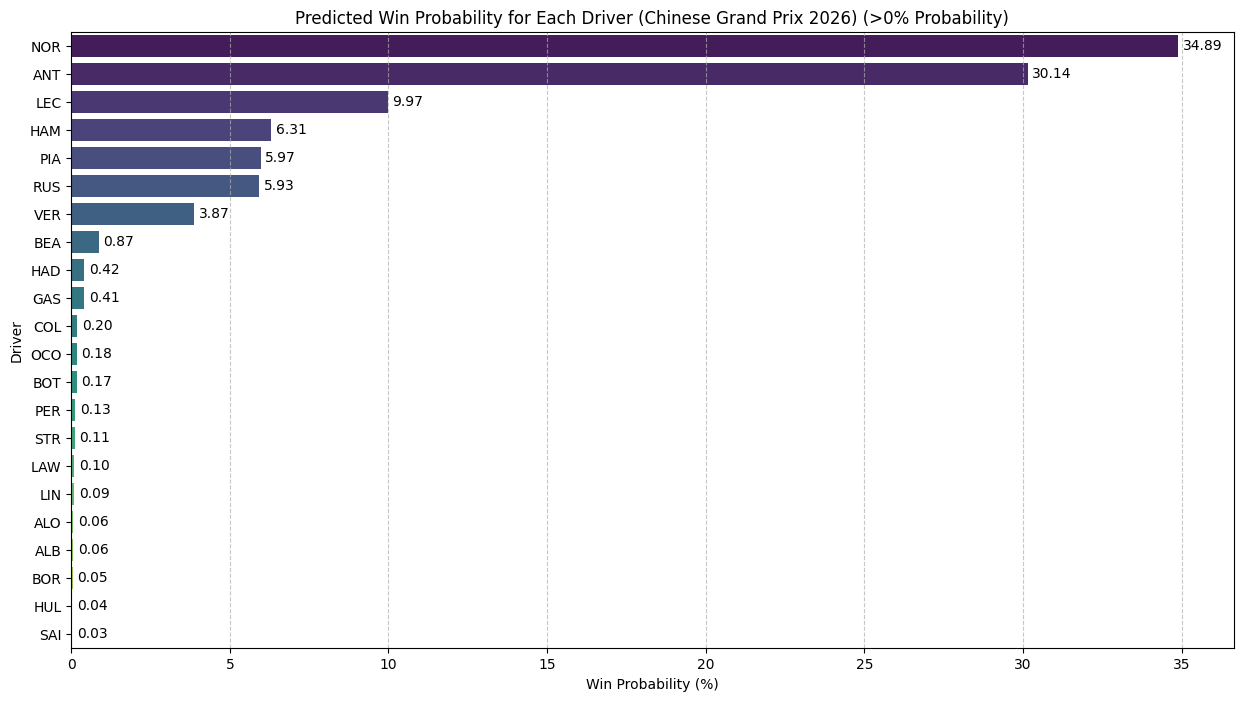

In [ ]:
# Sort the future_df by win_probability for better visualization
future_df_sorted = future_df.sort_values(by='win_probability', ascending=False)

# Filter to only show probabilities greater than 0.00%
future_df_filtered = future_df_sorted[future_df_sorted['win_probability'] > 0.00]

# defining the figure to plot the results on
plt.figure(figsize=(15, 8))

# creating a barchart to plot the percentages with the x-axis being the win probibility and the y-axis being the driver
bars = sns.barplot(x='win_probability', y='driver', hue='driver', data=future_df_filtered, palette='viridis', legend=False)


plt.xlabel('Win Probability (%)')
plt.ylabel('Driver')
plt.title('Predicted Win Probability for Each Driver (Chinese Grand Prix 2026) (>0% Probability)')

for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.15, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va="center")

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Raw Predicted Win Probability for Each Driver

This chart visualizes the raw win probabilities predicted by the model for each driver, *before* normalization. These values represent the model's confidence in each driver winning, but they do not necessarily sum to 100%.

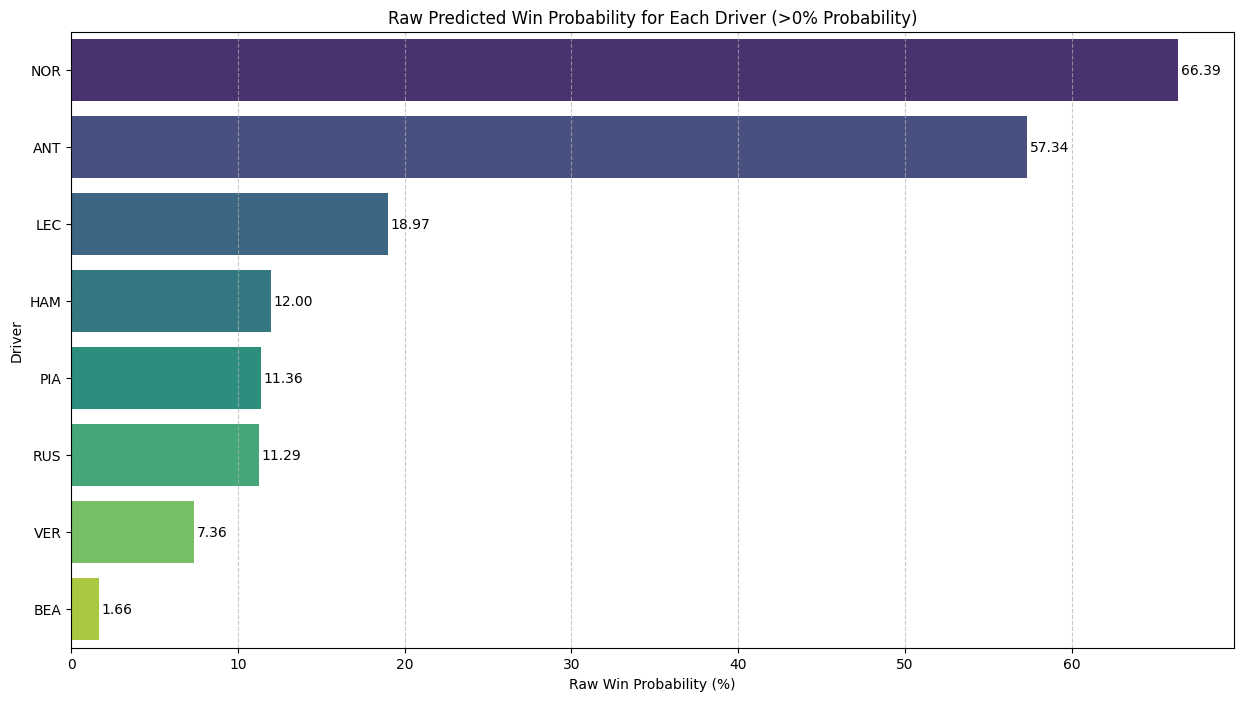

In [ ]:
# Sort the future_df by raw_win_probability for better visualization
future_df_sorted = future_df.sort_values(by='raw_win_probability', ascending=False)

# Filter to only show probabilities greater than 0.00%
future_df_filtered_raw = future_df_sorted[future_df_sorted['raw_win_probability'] > 1.00]

# defining the figure to plot the results on
plt.figure(figsize=(15, 8))

# creating a barchart to plot the percentages with the x-axis being the raw win probibility and the y-axis being the driver
bars = sns.barplot(x='raw_win_probability', y='driver', hue='driver', data=future_df_filtered_raw, palette='viridis', legend=False)

# giving the chart descriptive labels
plt.xlabel('Raw Win Probability (%)')
plt.ylabel('Driver')
plt.title('Raw Predicted Win Probability for Each Driver (>0% Probability)')

# this for loop is to format the percentages for each bar in the graph
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.15, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va="center")

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# at time of prediction the records from the last race should be present and not race being predicted.
df.tail()

,season,round,race_name,driver,team,grid_position,quali_position,finish_position,status,points,is_winner,driver_avg_finish_3,driver_win_rate_5,team_win_rate_5,cumulative_points,champ_rank,grid_x_form,champ_x_grid,team_form_x_grid
3619,2026,3,Japanese Grand Prix,PIA,McLaren,3,3.0,2,Finished,18.0,0,16.000000,0.0,0.0,0.0,21.0,48.000000,63.0,0.0
3620,2026,3,Japanese Grand Prix,RUS,Mercedes,2,2.0,4,Finished,12.0,0,12.000000,0.0,0.2,43.0,2.0,24.000000,4.0,0.4
3621,2026,3,Japanese Grand Prix,SAI,Williams,16,16.0,15,Finished,0.0,0,10.000000,0.0,0.2,2.0,13.0,160.000000,208.0,3.2
3622,2026,3,Japanese Grand Prix,STR,Aston Martin,22,22.0,21,DNF,0.0,0,9.666667,0.0,0.2,0.0,22.0,212.666667,484.0,4.4
3623,2026,3,Japanese Grand Prix,VER,Red Bull,11,11.0,8,Finished,4.0,0,14.333333,0.0,0.2,8.0,8.0,157.666667,88.0,2.2
